# NB101 - Combined-winner FULL training (aux_seg + gca_floor)

Trains the NB98 ablation winner on the **full 70k train / 10k val** split.

| Setting | Value | Source |
|---|---|---|
| `--use-aux-seg --aux-seg-classes 2` | training-only dense aux: **drivable + lane** | winner (abl_aux_seg) |
| `--aux-drivable-weight 0.5 --aux-lane-weight 0.5` | aux term weights | — |
| `--seg-gate-floor 0.3` | force lane GCA decoupling | 2nd (abl_gca_floor) |
| `--lane-weights clrkd` `--diff-clamp 100` `--lane-match hungarian` | proven geometry recipe | NB97 |
| `--fliplr 0.5` `--weight-decay 0.05` | regularization | NB97 |
| `--epochs 120` `--patience 30` `--batch 32` `--lr0 4e-4` | budget | NB97 |

**Drivable area:** Cell 3's `USE_DRIVABLE=True` (default) feeds the aux head the
drivable masks from NB102's `bdd_complete_labels_70k.tar.gz` (verified 100%
coverage: 80000/80000). The aux head is **training-only** - it is dropped at
eval, so inference is unchanged (still detection + CLR polyline lane only). The
extra dense drivable gradient further fights negative transfer. Set
`USE_DRIVABLE=False` to revert to the NB98-winner lane-only aux.

**Headline metric to watch: `metrics/lane_curveIoU(lane)` and
`metrics/lane_f1(lane)`** (the fixed un-saturated metric). Detection mAP50
should hold ~0.70 (asym_lr was dropped precisely because it crashed mAP50).

**How to run (fresh Colab session):** Cells 1-3 prep (mount, install deps,
extract images/bbox/polyline + drivable masks to /content/, point the YAML at
it). Cell 4 launches the run; best.pt/last.pt + full_train.log sync to Drive
every epoch (resume-safe: re-run Cell 4 to continue). Cell 5 reads back the
trajectory.

> Per the Colab `/content/` isolation rule, the dataset MUST be extracted to
> `/content/` (not Drive), and re-extracted at the start of every new session.


### Cell 1: Mount Drive + install deps

In [4]:
import os, sys, subprocess
from pathlib import Path

os.environ['PYTHONIOENCODING'] = 'utf-8'
if not Path('/content/drive').exists():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing {REPO_ROOT} -- verify Drive sync.')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# clrkd (imported by the model) needs addict/yapf; mmcv pulls them in too.
for _pkg in ('addict', 'yapf'):
    try: __import__(_pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pkg])
try:
    import mmcv  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mmcv'])

MIG   = Path(REPO_ROOT) / 'stage2/rmt_ppad_migration'
TRAIN = MIG / 'P8_train/scripts/train_lane_only.py'
MODEL = MIG / 'vendor/RMT-PPAD/ultralytics/cfg/models/mt-detr/rtdetr-l_bdd_clr_lane.yaml'
DATA  = MIG / 'vendor/RMT-PPAD/ultralytics/cfg/datasets/BDD_lane_only.yaml'
DATASETS  = Path('/content/drive/MyDrive/EcoCAR/datasets')
for p in (TRAIN, MODEL, DATA):
    assert p.exists(), f'missing {p}'
print('[ok] env ready; cwd =', os.getcwd())


[ok] env ready; cwd = /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane


### Cell 2: Extract the FULL 70k/10k dataset to /content/

Idempotent (skips if already present). MUST extract to /content/ (NOT Drive)
per the small-files rule. ~several minutes the first time. Uses the SAME
prep script + output dir (`/content/bdd_dataset`) NB97 used for its 70k run.


In [5]:
# Same full-data prep NB97 used (verified on disk): P8 prepare_bdd_subset.py at
# 70k/10k -> /content/bdd_dataset. (No separate "full" prep script exists.)
PREP = MIG / 'P8_train/scripts/prepare_bdd_subset.py'
FULL = Path('/content/bdd_dataset')
req = [Path('/content/drive/MyDrive/EcoCAR/datasets/bdd100k_clrkd_curve.tar'),
       Path('/content/drive/MyDrive/EcoCAR/downloads/rmt_ppad_weights/BDD_detection_labels.zip'),
       Path('/content/drive/MyDrive/EcoCAR/datasets/lane_targets_clr_v1_polyline.tar.gz')]
missing = [str(p) for p in req if not p.exists()]
if missing:
    raise FileNotFoundError('Missing Drive inputs:\n  ' + '\n  '.join(missing))
assert PREP.exists(), f'prep script missing (sync Drive): {PREP}'

if (FULL / '.prep_done').exists() or (
        (FULL / 'images/val2017').exists() and any((FULL / 'images/val2017').iterdir())):
    print(f'[ok] full dataset already at {FULL}; skipping extraction')
else:
    cmd = [sys.executable, '-u', str(PREP), '--out-root', str(FULL),
           '--n-train', '70000', '--n-val', '10000', '--seed', '88']
    print('  ', ' '.join(cmd), flush=True)
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout: print(line, end='', flush=True)
    if p.wait() != 0:
        raise RuntimeError('full prep failed - see streamed output above.')
    (FULL / '.prep_done').write_text('ok')

for lab, d in (('images/train', FULL/'images/train2017'), ('images/val', FULL/'images/val2017'),
               ('lane_tgt/train', FULL/'lane_targets/train2017'), ('lane_tgt/val', FULL/'lane_targets/val2017')):
    n = sum(1 for _ in d.iterdir()) if d.exists() else 0
    print(f'  {lab:16s} {n}')
assert (FULL/'images/val2017').exists(), 'val images missing after prep'


[ok] full dataset already at /content/bdd_dataset; skipping extraction
  images/train     70000
  images/val       10000
  lane_tgt/train   70000
  lane_tgt/val     10000


### Cell 3: Point the data YAML at /content/ + (optional) drivable masks

`USE_DRIVABLE = True` (default) makes the aux head supervise BOTH drivable area
AND lane segmentation. It pulls the drivable masks from NB102's complete-dataset
tar (`bdd_complete_labels_70k.tar.gz`, 100% coverage - 80000/80000 masks) into
`/content/bdd_dataset/drivable_masks/`, then ZERO-FILLS any stem the tar somehow
misses so EVERY image has a 2-channel [drivable, lane] target. That uniform
channel count is mandatory: the loader prepends a drivable channel only when the
file exists, so partial coverage -> mixed 1-/2-channel masks -> the NB98
`torch.stack` collate crash. Set `USE_DRIVABLE = False` to revert to the proven
lane-only aux (the exact NB98-winner config).


In [6]:
USE_DRIVABLE = True   # True = aux supervises drivable + lane; False = lane-only

def _yset(yaml_path, field, value):
    txt = yaml_path.read_text(encoding='utf-8'); line = f'{field}: {value}'
    if line in txt: return
    lines = txt.splitlines()
    for i, ln in enumerate(lines):
        if ln.strip().startswith(f'{field}:'): lines[i] = line; break
    else: lines.append(line)
    yaml_path.write_text('\n'.join(lines) + '\n', encoding='utf-8'); print(f'  [yaml] {field} -> {value}')

def _yunset(yaml_path, field):
    txt = yaml_path.read_text(encoding='utf-8')
    keep = [ln for ln in txt.splitlines() if not ln.strip().startswith(f'{field}:')]
    new = '\n'.join(keep) + '\n'
    if new != txt: yaml_path.write_text(new, encoding='utf-8'); print(f'  [yaml] removed {field}')

_yset(DATA, 'path', '/content/bdd_dataset')
_yset(DATA, 'lane_targets_root', '/content/bdd_dataset/lane_targets')

DA_ROOT = FULL / 'drivable_masks'
if USE_DRIVABLE:
    import tarfile, cv2, numpy as np
    # 1. Ensure drivable masks are on /content/. Prefer NB102's tar (one file,
    #    small-files rule); fall back to extracting the raw zip if the tar is
    #    absent. /content/ is wiped each session, so re-extract every run.
    have = sum(1 for _ in (DA_ROOT/'val2017').glob('*.png')) if (DA_ROOT/'val2017').exists() else 0
    if have == 0:
        tar = DATASETS / 'bdd_complete_labels_70k.tar.gz'
        if tar.exists():
            print(f'[da] extracting {tar.name} -> {FULL}', flush=True)
            with tarfile.open(tar) as tf:
                tf.extractall(FULL)   # writes drivable_masks/ (+ labels/, lane_targets/, manifest.json)
        else:
            zipf = DOWNLOADS / 'bdd100k_drivable_maps.zip'
            if not zipf.exists():
                raise FileNotFoundError(
                    f'Neither {tar} nor {zipf} found. Run NB102 first, or place '
                    'the drivable zip on Drive. (Or set USE_DRIVABLE=False.)')
            print(f'[da] tar missing; extracting masks from {zipf.name} via NB102 helper', flush=True)
            cmd = [sys.executable, '-u', str(MIG/'aux_seg/tools/extract_drivable_subset.py'),
                   '--seg-zip', str(zipf), '--subset-root', str(FULL),
                   '--splits', 'train2017', 'val2017']
            subprocess.run(cmd, check=True)
    # 2. Zero-fill any missing stem so coverage is EXACTLY 100% (collate safety).
    filled = 0
    for split in ('train2017', 'val2017'):
        img_d = FULL/'images'/split; da_d = DA_ROOT/split
        da_d.mkdir(parents=True, exist_ok=True)
        for jp in img_d.glob('*.jpg'):
            mp = da_d / f'{jp.stem}.png'
            if not mp.exists():
                cv2.imwrite(str(mp), np.zeros((720, 1280), np.uint8)); filled += 1
    # 3. Report coverage and wire the yaml.
    for split in ('train2017', 'val2017'):
        ni = sum(1 for _ in (FULL/'images'/split).glob('*.jpg'))
        nd = sum(1 for _ in (DA_ROOT/split).glob('*.png'))
        print(f'  {split}: DA {nd}/{ni}  ({100*nd/max(1,ni):.1f}%)')
    if filled: print(f'  [da] zero-filled {filled} missing stem(s) for collate safety')
    _yset(DATA, 'drivable_masks_root', str(DA_ROOT))
    print('[ok] data yaml configured: drivable + lane aux ->', DATA.name)
else:
    _yunset(DATA, 'drivable_masks_root')
    print('[ok] data yaml configured (lane-only aux):', DATA.name)


[da] extracting bdd_complete_labels_70k.tar.gz -> /content/bdd_dataset


/tmp/ipykernel_781/895017760.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(FULL)   # writes drivable_masks/ (+ labels/, lane_targets/, manifest.json)


  train2017: DA 70000/70000  (100.0%)
  val2017: DA 10000/10000  (100.0%)
  [yaml] drivable_masks_root -> /content/bdd_dataset/drivable_masks
[ok] data yaml configured: drivable + lane aux -> BDD_lane_only.yaml


### Cell 3b: VISUAL DATASET INSPECTION (run BEFORE training)

Draws, for a few sample images, all three GT modalities overlaid so you can
eyeball that each is complete and correctly aligned BEFORE spending GPU hours:
- **Drivable area (DA)** - cyan translucent fill from `drivable_masks/<split>/<stem>.png`
- **Lane polylines** - green lines decoded from the 78-D `lane_targets/<split>/<stem>.pt`
- **Bounding boxes** - red boxes from the YOLO `labels/<split>/<stem>.txt` (class 0=vehicle)

It also prints **coverage stats**: how many of the subset images actually have
each modality. DA coverage in particular is expected to be LOW here (the BDD
seg-maps zip only overlaps a fraction of the 70k curve subset) - the run still
works because the aux loss skips DA when its mask is absent, but this cell tells
you the true number so there are no surprises.


[val2017] 10000 images
  lane_targets : 10000/10000  (100.0%)
  det labels   : 10000/10000  (100.0%)
  drivable DA  : 10000/10000  (100.0%)
  showing: ['c18d3ffa-befc072e', 'c2f92f94-43481d10', 'b37693d0-cd9bdf88', 'bca3720a-642376aa']  (DA-present)


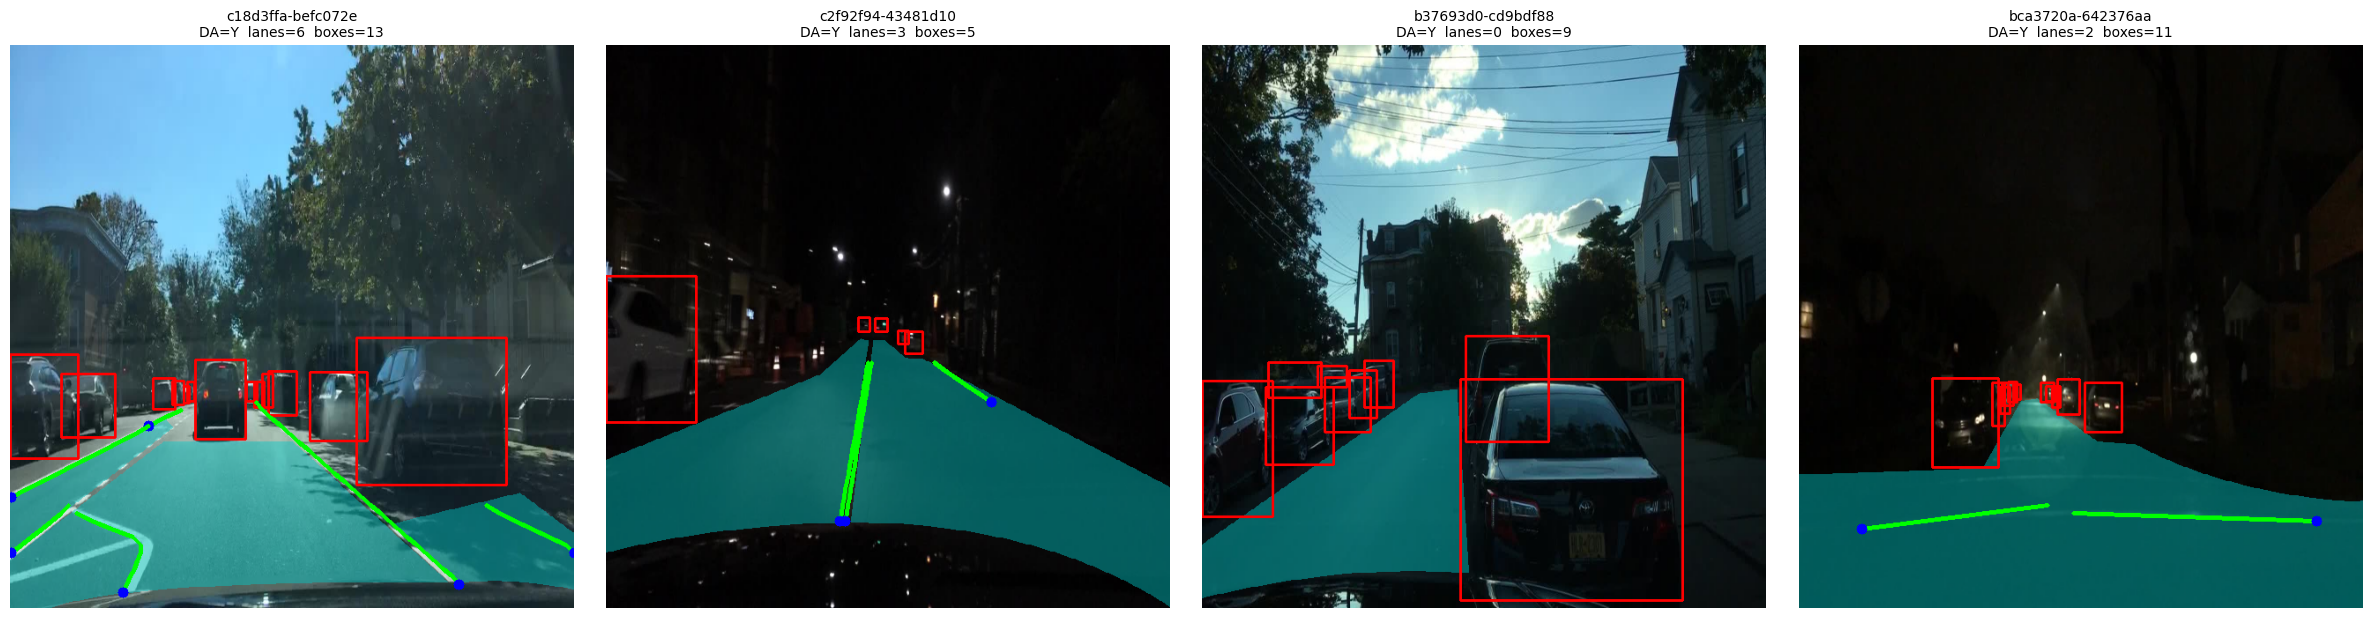

[saved] /content/dataset_inspection.png
VERDICT: green lanes must hug road markings, red boxes wrap vehicles, cyan DA covers the road. If any modality is misaligned/empty -> report BEFORE training.


In [7]:
import numpy as np, cv2, torch, random
from pathlib import Path
import matplotlib.pyplot as plt

SPLIT = 'val2017'          # inspect val (smaller); switch to 'train2017' if wanted
N_SHOW = 4
S = 640                    # P1 squashes to 640x640; match it for overlay alignment
NP_, NS = 72, 71
YS = np.arange(S, -1, -S/NS)[:NP_]   # slot -> y(px); GT length is in STRIP count

ROOT   = Path('/content/bdd_dataset')
img_dir = ROOT/'images'/SPLIT
tgt_dir = ROOT/'lane_targets'/SPLIT
lbl_dir = ROOT/'labels'/SPLIT
da_dir  = ROOT/'drivable_masks'/SPLIT
assert img_dir.exists(), f'no images at {img_dir} - run Cells 1-2 first'

stems = sorted(p.stem for p in img_dir.glob('*.jpg'))
print(f'[{SPLIT}] {len(stems)} images')

# ---- coverage stats across the whole split ----
def _cov(d, ext):
    if not d.exists(): return 0
    have = {p.stem for p in d.glob(f'*{ext}')}
    return sum(1 for s in stems if s in have)
n_tgt = _cov(tgt_dir, '.pt'); n_lbl = _cov(lbl_dir, '.txt'); n_da = _cov(da_dir, '.png')
N = max(1, len(stems))
print(f'  lane_targets : {n_tgt}/{len(stems)}  ({100*n_tgt/N:.1f}%)')
print(f'  det labels   : {n_lbl}/{len(stems)}  ({100*n_lbl/N:.1f}%)')
print(f'  drivable DA  : {n_da}/{len(stems)}  ({100*n_da/N:.1f}%)'
      + ('   <-- LOW (expected): aux DA term is skipped where absent' if n_da < N*0.5 else ''))

def decode_lanes(t):
    out = []
    for row in t:
        if float(row[1]) < 0.5: continue
        start = max(0, min(int(round(float(row[2])*NS)), NP_))
        length = max(0, min(int(round(float(row[5]))), NP_-start))  # GT: strip count
        if length < 2: continue
        xs = np.asarray(row[6+start:6+start+length], dtype=float)
        ys = YS[start:start+length]
        pts = [(int(round(x)), int(round(y))) for x, y in zip(xs, ys)
               if np.isfinite(x) and 0 <= x < S]
        if len(pts) >= 2: out.append(np.array(pts, dtype=np.int32))
    return out

def read_boxes(p):
    """YOLO txt -> list of (x1,y1,x2,y2) in the 640 frame."""
    boxes = []
    if not p.exists(): return boxes
    for ln in p.read_text().splitlines():
        f = ln.split()
        if len(f) < 5: continue
        cx, cy, w, h = (float(v) for v in f[1:5])   # normalized
        x1 = (cx-w/2)*S; y1 = (cy-h/2)*S; x2 = (cx+w/2)*S; y2 = (cy+h/2)*S
        boxes.append((int(x1), int(y1), int(x2), int(y2)))
    return boxes

# Prefer samples that HAVE a drivable mask (so DA is visible); fall back to any.
with_da = [s for s in stems if (da_dir/f'{s}.png').exists()]
random.seed(0)
pick = (random.sample(with_da, min(N_SHOW, len(with_da))) if with_da else [])
pick += random.sample(stems, max(0, N_SHOW - len(pick)))
pick = pick[:N_SHOW]
print(f'  showing: {pick}  ({"DA-present" if with_da else "no DA available -> lanes+boxes only"})')

fig, axes = plt.subplots(1, len(pick), figsize=(6*len(pick), 6))
if len(pick) == 1: axes = [axes]
for ax, st in zip(axes, pick):
    img = cv2.cvtColor(cv2.imread(str(img_dir/f'{st}.jpg')), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (S, S))
    ov = img.copy()
    # DA: cyan translucent fill
    da_p = da_dir/f'{st}.png'
    has_da = da_p.exists()
    if has_da:
        m = cv2.imread(str(da_p), cv2.IMREAD_GRAYSCALE)
        m = cv2.resize(m, (S, S), interpolation=cv2.INTER_NEAREST) > 0
        tint = ov.copy(); tint[m] = (0, 200, 200)
        ov = cv2.addWeighted(tint, 0.45, ov, 0.55, 0)
    # boxes: red
    bxs = read_boxes(lbl_dir/f'{st}.txt')
    for (x1,y1,x2,y2) in bxs:
        cv2.rectangle(ov, (x1,y1), (x2,y2), (255,0,0), 2)
    # lanes: green + blue start dot
    lanes = []
    tgt_p = tgt_dir/f'{st}.pt'
    if tgt_p.exists():
        tt = torch.load(tgt_p, weights_only=True)
        t = tt.numpy() if hasattr(tt,'numpy') else np.asarray(tt)
        lanes = decode_lanes(t.astype(np.float32))
        for pts in lanes:
            cv2.polylines(ov, [pts.reshape(-1,1,2)], False, (0,255,0), 3)
            cv2.circle(ov, tuple(pts[0]), 6, (0,0,255), -1)
    ax.imshow(ov); ax.axis('off')
    ax.set_title(f'{st}\nDA={"Y" if has_da else "N"}  lanes={len(lanes)}  boxes={len(bxs)}', fontsize=10)
plt.tight_layout()
out_png = '/content/dataset_inspection.png'; plt.savefig(out_png, dpi=80); plt.show()
print(f'[saved] {out_png}')
print('VERDICT: green lanes must hug road markings, red boxes wrap vehicles, '
      'cyan DA covers the road. If any modality is misaligned/empty -> report BEFORE training.')


### Cell 4: Launch the combined-winner full run (resume-safe)

`--use-aux-seg --aux-seg-classes 2 --seg-gate-floor 0.3` on top of the proven
NB97 recipe. Re-run this cell to resume from the last checkpoint.


In [ ]:
from stage2.scripts.notebook_utils import run_streaming

ROW = 'combined_aux_gca_full'
PROJECT = '/content/runs/combined_full'
LOG_DIR = '/content/drive/MyDrive/EcoCAR/training_runs/notebook_logs'
os.makedirs(LOG_DIR, exist_ok=True)
EPOCHS, BATCH, LR0, PATIENCE = 120, 32, '4e-4', 30

cmd = [sys.executable, '-u', str(TRAIN),
       '--mode', 'full', '--model-yaml', str(MODEL), '--data-yaml', str(DATA),
       '--project', PROJECT, '--name', ROW,
       '--save-period', '10', '--batch', str(BATCH), '--epochs', str(EPOCHS),
       '--lr0', LR0, '--patience', str(PATIENCE),
       '--fliplr', '0.5', '--weight-decay', '0.05',
       '--lane-match', 'hungarian', '--lane-weights', 'clrkd', '--diff-clamp', '100',
       # === the NB98 winner combination ===
       '--use-aux-seg', '--aux-seg-classes', '2',
       '--aux-drivable-weight', '0.5', '--aux-lane-weight', '0.5',
       '--seg-gate-floor', '0.3']
_da = 'drivable+lane' if 'drivable_masks_root' in DATA.read_text(encoding='utf-8') else 'lane-only'
print(f'=== combined_aux_gca_full: aux_seg ({_da}) + gca_floor on FULL data ===')
print('   ', ' '.join(cmd[3:]), flush=True)
rc = run_streaming(cmd, log_path=os.path.join(LOG_DIR, f'NB101_{ROW}.log'), check=False)
print(f'[{ROW}] rc={rc}  (watch metrics/lane_curveIoU(lane) + metrics/lane_f1(lane))')


流式输出内容被截断，只能显示最后 5000 行内容。
     14/120      99.5G      13.85     0.0715      4.011  0.0003886      71.01     0.6193     0.5843        322        640:  92%|█████████▏| 2006/2188 [30:36<02:46,  1.09it/s]
     14/120      99.5G      13.85     0.0715      4.011  0.0003886      71.01     0.6203     0.5839        325        640:  92%|█████████▏| 2006/2188 [30:37<02:46,  1.09it/s]
     14/120      99.5G      13.85    0.07149      4.011  0.0003886      76.52     0.6201     0.5839        309        640:  92%|█████████▏| 2006/2188 [30:38<02:46,  1.09it/s]
     14/120      99.5G      13.85    0.07149      4.011  0.0003886      76.52     0.6197     0.5835        341        640:  92%|█████████▏| 2006/2188 [30:39<02:46,  1.09it/s]
     14/120      99.5G      13.85    0.07149       4.01  0.0003886      52.75     0.6202     0.5839        367        640:  92%|█████████▏| 2006/2188 [30:39<02:46,  1.09it/s]
     14/120      99.5G      13.85    0.07148       4.01  0.0003886      52.75     0.6197     0.583

### Cell 5: Read back the trajectory (curveIoU / F1 / mAP50 per epoch)

Reads `results.csv` for the run and prints the lane + detection curves so you
can confirm: curveIoU/F1 climb, mAP50 holds ~0.70, and (the original goal) no
post-ep10 collapse.


In [ ]:
import csv
from pathlib import Path

RUN = Path('/content/runs/combined_full/combined_aux_gca_full')
DRIVE_RUN = Path('/content/drive/MyDrive/EcoCAR/training_runs/checkpoints/combined_aux_gca_full')
csvp = (RUN / 'results.csv') if (RUN / 'results.csv').exists() else (DRIVE_RUN / 'results.csv')  # noqa: E501
if not csvp.exists():
    print(f'[wait] no results.csv yet at {csvp} - run Cell 4 first / let it reach epoch 1.')
else:
    rows = [{k.strip(): v for k, v in r.items()} for r in csv.DictReader(open(csvp))]
    def col(key):
        out = []
        for r in rows:
            try: out.append(float(r.get(key, '')))
            except: out.append(None)
        return out
    ep   = [r.get('epoch','').strip() for r in rows]
    cIoU = col('metrics/lane_curveIoU(lane)'); f1 = col('metrics/lane_f1(lane)')
    iou  = col('metrics/IoU(lane)'); m50 = col('metrics/mAP50(B)')
    def f(x): return f'{x:.4f}' if isinstance(x, float) else '  -  '
    print(f'{"ep":>3} {"curveIoU":>9} {"F1":>8} {"pixIoU":>8} {"mAP50":>8}')
    for i in range(len(rows)):
        print(f'{ep[i]:>3} {f(cIoU[i]):>9} {f(f1[i]):>8} {f(iou[i]):>8} {f(m50[i]):>8}')
    if any(v is not None for v in f1):
        best = max((v for v in f1 if v is not None), default=None)
        print(f'\nbest lane_f1 = {best}.  Compare to NB98 10k abl_aux_seg F1=0.211.')
